# Katalog Keşifsel Veri Analizi (EDA)

Bu defter, `data/processed/` altındaki işlenmiş kataloğu **sınar** — süs grafik üretmez.
Her bölüm somut bir soruyu cevaplar ve cevap beklenenden saparsa bu, boru hattında
düzeltilmesi gereken bir sorunun işaretidir.

| # | Soru | Neden önemli |
|---|---|---|
| 1 | Kaynaklar ve zaman kapsamı nedir? | Birleştirmenin gerçekten dört kaynağı kapsadığını doğrular |
| 2 | Büyüklük tipleri zaman içinde nasıl değişiyor? | Mw dönüşümü bu bileşime göre uygulanır; kayması sistematik hata üretir |
| 3 | Tamlık (Mc) zamanla nasıl değişti? | Dönem bazlı Mc seçimimizin veriye uyup uymadığı |
| 4 | Gutenberg-Richter yasası tutuyor mu? | Tutmuyorsa katalog ya eksik ya kirli |
| 5 | Depremler nerede? | Fay hatlarıyla örtüşmeli — örtüşmüyorsa konum verisi bozuk |
| 6 | Declustering fiziksel olarak doğru mu? | Artçı dizileri Omori yasasına uymalı |
| 7 | Hedef etiketler nasıl dağılmış? | Modelin öğreneceği sinyalin seyrekliği |
| 8 | Veride kirlilik var mı? | Derinlik yığılmaları, patlatma kalıntısı, kopya kayıt |

> **Not:** Grafikler hem defterde gömülü hem de `docs/eda/` altına PNG olarak yazılır.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.ingest.catalog_io import read_catalog

PROC = ROOT / "data" / "processed"
FIGS = ROOT / "docs" / "eda"
FIGS.mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

def save(fig, name):
    fig.savefig(FIGS / f"{name}.png", dpi=130, bbox_inches="tight")

cat = read_catalog(PROC / "catalog_merged.csv")
dec = read_catalog(PROC / "catalog_declustered.csv")
mc_tbl = pd.read_csv(PROC / "mc_by_period.csv")
print(f"birleşik katalog : {len(cat):,} olay")
print(f"ayrıştırılmış    : {len(dec):,} olay (Mc üstü)")
print(f"zaman aralığı    : {cat.time.min():%Y-%m-%d} -> {cat.time.max():%Y-%m-%d}")

birleşik katalog : 304,168 olay
ayrıştırılmış    : 50,340 olay (Mc üstü)
zaman aralığı    : 1904-08-11 -> 2026-08-21


## 1. Kaynaklar ve zaman kapsamı

Beklenti: AFAD 2003'ten itibaren baskın (ulusal ağ, en yoğun kapsam), USGS tarihsel
derinliği tek başına taşıyor, KOERI 1970'ten itibaren katkı veriyor.

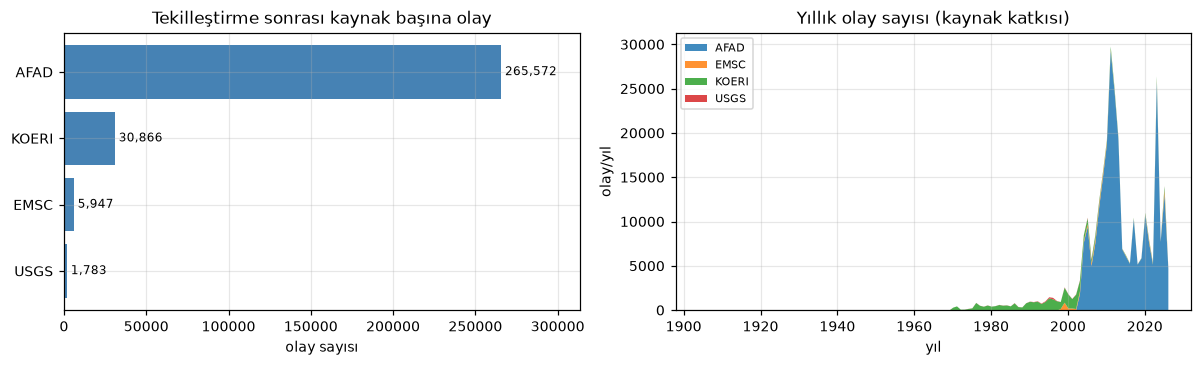

,ilk olay,son olay,olay
source,,,
AFAD,2003-01-02 08:43:14.770000+00:00,2026-08-21 18:33:43+00:00,265572
EMSC,1998-01-02 00:34:18.300000+00:00,2026-08-19 09:50:16.100000+00:00,5947
KOERI,1970-01-01 14:18:03.600000+00:00,2026-06-30 07:13:25.710000+00:00,30866
USGS,1904-08-11 06:06:57.300000+00:00,2026-07-06 05:01:33.292000+00:00,1783


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

counts = cat.source.value_counts()
axes[0].barh(counts.index[::-1], counts.values[::-1], color="steelblue")
for i, v in enumerate(counts.values[::-1]):
    axes[0].text(v, i, f" {v:,}", va="center", fontsize=8)
axes[0].set_title("Tekilleştirme sonrası kaynak başına olay")
axes[0].set_xlabel("olay sayısı")
axes[0].set_xlim(0, counts.max() * 1.18)

pivot = (cat.assign(yil=cat.time.dt.year)
            .pivot_table(index="yil", columns="source", values="mw", aggfunc="size")
            .fillna(0))
pivot.plot.area(ax=axes[1], lw=0, alpha=0.85)
axes[1].set_title("Yıllık olay sayısı (kaynak katkısı)")
axes[1].set_xlabel("yıl"); axes[1].set_ylabel("olay/yıl")
axes[1].legend(fontsize=7, loc="upper left")
save(fig, "01_kaynaklar"); plt.show()

span = cat.groupby("source").time.agg(["min", "max", "size"])
span.columns = ["ilk olay", "son olay", "olay"]
display(span)

**Okuma:** 2003 sonrası dikey sıçrama AFAD'ın devreye girmesidir — gerçek bir
sismisite artışı değil, **ağ kapsamındaki değişimdir**. Modelin bunu deprem
aktivitesi artışı sanmaması için tamlık düzeltmesi (Mc) tam da bu yüzden zorunlu.
2023'teki tepe ise gerçek: Kahramanmaraş artçı dizisi.

## 2. Büyüklük tipi bileşimi

Her tip farklı bir bağıntıyla Mw'ye çevrilir (`src/ingest/mw_calibration.py`).
Bileşim zaman içinde kayıyorsa, dönüşüm hatası da zaman içinde kayar — yani
sahte bir "trend" üretebilir. Bu grafik o riski görünür kılar.

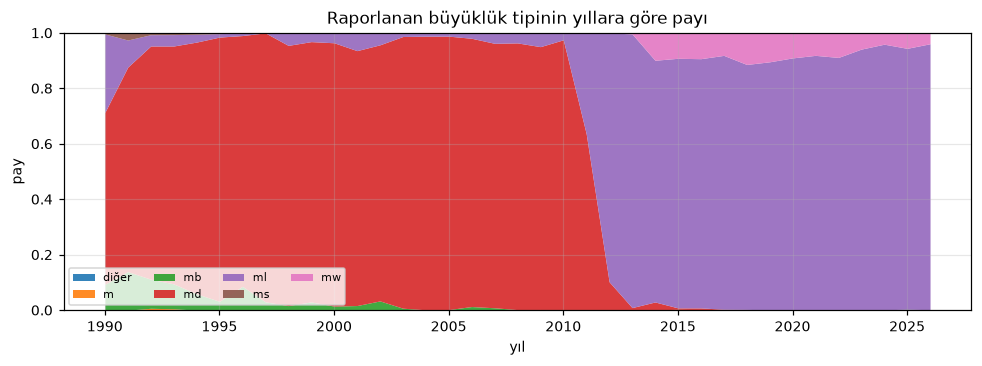

Kalibre edilmiş dönüşümler (KOERI çiftlerinden regresyon):
  ML  -> Mw = 1.039*ML -0.138   (n=16848, R²=0.919, RMS=0.149)
  MD  -> Mw = 1.031*MD +0.045   (n=  522, R²=0.930, RMS=0.110)
  MS  -> Mw = 0.781*MS +1.254   (n=  514, R²=0.945, RMS=0.090)
  MB  -> Mw = 1.206*MB -0.760   (n=  538, R²=0.917, RMS=0.110)


In [3]:
tip = cat.assign(yil=cat.time.dt.year,
                 tip=cat.mag_type.astype(str).str.lower().str.strip())
top = tip.tip.value_counts().head(6).index
tip["tip"] = tip.tip.where(tip.tip.isin(top), "diğer")
share = (tip.pivot_table(index="yil", columns="tip", values="mw", aggfunc="size")
            .fillna(0))
share = share.div(share.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 3.4))
share.loc[1990:].plot.area(ax=ax, lw=0, alpha=0.9)
ax.set_title("Raporlanan büyüklük tipinin yıllara göre payı")
ax.set_xlabel("yıl"); ax.set_ylabel("pay"); ax.set_ylim(0, 1)
ax.legend(fontsize=7, ncol=4, loc="lower left")
save(fig, "02_buyukluk_tipleri"); plt.show()

print("Kalibre edilmiş dönüşümler (KOERI çiftlerinden regresyon):")
import json
conv = json.loads((PROC / "mw_conversion.json").read_text())
for k, v in conv["relations"].items():
    print(f"  {k.upper():3s} -> Mw = {v['slope']:.3f}*{k.upper()} {v['intercept']:+.3f}"
          f"   (n={v['n']:5d}, R²={v['r2']:.3f}, RMS={v['rms']:.3f})")

## 3. Tamlık büyüklüğü (Mc) zaman içinde

Dönem bazlı Mc'yi `src/features/completeness.py` hesaplıyor. Burada bağımsız bir
kontrol yapıyoruz: kayan pencerede MAXC tahmincisi, seçtiğimiz dönemsel değerlerle
uyuşuyor mu?

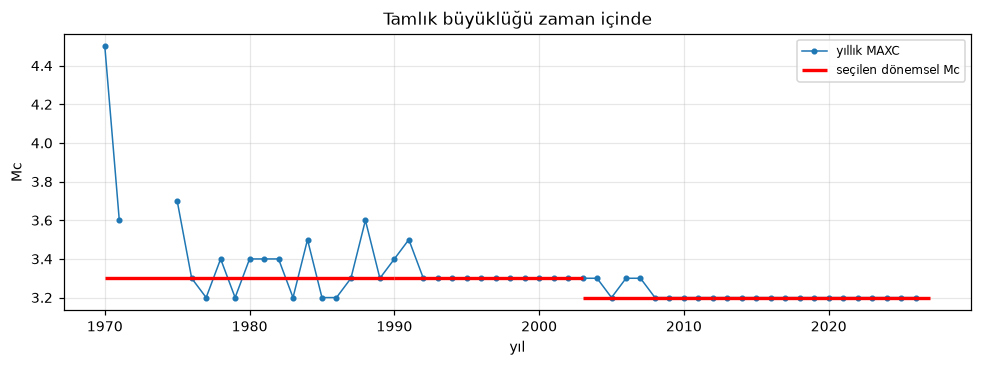

,period,n,mc_maxc,mc_gft,mc_mbs,mc,b,b_sigma
0,1900-1970,513,5.6,NaN,5.4,5.6,1.01,0.07
1,1970-1990,9740,3.3,NaN,3.6,3.3,0.65,0.01
2,1990-2003,17563,3.3,3.7,3.1,3.3,0.95,0.01
3,2003-2012,113858,3.2,3.6,4.4,3.2,1.35,0.01
4,2012-2020,84945,3.2,3.1,3.9,3.2,0.86,0.01
5,2020+,77549,3.2,3.0,3.9,3.2,0.82,0.01


In [4]:
def maxc(mags, floor=3.0, bin_w=0.1):
    m = mags[mags >= floor]
    if len(m) < 200:
        return np.nan
    edges = np.arange(floor - bin_w / 2, m.max() + bin_w, bin_w)
    counts, _ = np.histogram(m, bins=edges)
    return edges[counts.argmax()] + bin_w / 2 + 0.2

yearly = (cat[cat.time.dt.year >= 1970]
          .groupby(cat.time.dt.year).mw.apply(lambda s: maxc(s.to_numpy())))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(yearly.index, yearly.values, "o-", ms=3, lw=1, label="yıllık MAXC")
for _, r in mc_tbl.iterrows():
    if r.period == "1900-1970":
        continue
    y0 = int(r.period[:4]); y1 = 2027 if "+" in r.period else int(r.period[-4:])
    ax.hlines(r.mc, y0, y1, color="red", lw=2.2,
              label="seçilen dönemsel Mc" if y0 == 1970 else None)
ax.set_title("Tamlık büyüklüğü zaman içinde")
ax.set_xlabel("yıl"); ax.set_ylabel("Mc"); ax.legend(fontsize=8)
save(fig, "03_mc_zaman"); plt.show()

display(mc_tbl[["period", "n", "mc_maxc", "mc_gft", "mc_mbs", "mc", "b", "b_sigma"]]
        .round(2))

**Okuma:** Yıllık MAXC ile seçilen dönemsel Mc birbirine yakın seyretmeli. Kırmızı
çizgi noktaların belirgin ALTINDA kalırsa katalog o dönemde eksik demektir ve
model, olmayan depremleri "olmadı" sanır (sahte sismik sessizlik).

Tablodaki `mc_mbs` sütununun komşu dönemler arasında zıplaması, o tahmincinin bu
karışık katalogda güvenilmez olduğunun kanıtıdır — bu yüzden `mc` olarak MAXC
seçiliyor (bkz. `completeness.py` içindeki gerekçe).

## 4. Gutenberg-Richter yasası

log10 N(≥M) = a − b·M. Mc üstünde düz bir çizgi bekleriz. Kırılma veya bükülme,
tamlık sorununa ya da katalog kirliliğine işaret eder.

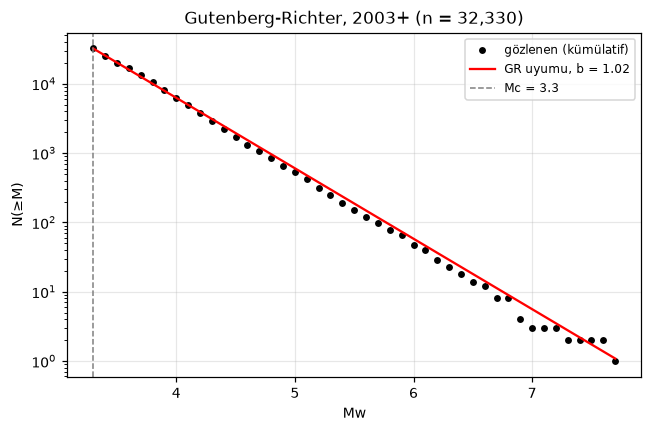

b = 1.017
GR'den beklenen M>=5.0 olay sayısı :      605
Katalogda gözlenen M>=5.0          :      534
GR'den beklenen M>=6.0             :       58
Katalogda gözlenen M>=6.0          :       47


In [5]:
mc_model = float(mc_tbl[mc_tbl.period.str.slice(0, 4).astype(int) >= 1990].mc.max())
sub = cat[(cat.time >= pd.Timestamp("2003-01-01", tz="UTC")) & (cat.mw >= mc_model)]
mags = sub.mw.to_numpy()

edges = np.arange(mc_model - 0.05, mags.max() + 0.1, 0.1)
counts, _ = np.histogram(mags, bins=edges)
centers = edges[:-1] + 0.05
cum = counts[::-1].cumsum()[::-1]

b = np.log10(np.e) / (mags.mean() - (mc_model - 0.05))
a = np.log10(len(mags)) + b * mc_model

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(centers, cum, "ko", ms=3.5, label="gözlenen (kümülatif)")
ax.semilogy(centers, 10 ** (a - b * centers), "r-", lw=1.5,
            label=f"GR uyumu, b = {b:.2f}")
ax.axvline(mc_model, color="gray", ls="--", lw=1, label=f"Mc = {mc_model:.1f}")
ax.set_xlabel("Mw"); ax.set_ylabel("N(≥M)")
ax.set_title(f"Gutenberg-Richter, 2003+ (n = {len(mags):,})")
ax.legend(fontsize=8)
save(fig, "04_gutenberg_richter"); plt.show()

print(f"b = {b:.3f}")
print(f"GR'den beklenen M>=5.0 olay sayısı : {10**(a-b*5.0):8.0f}")
print(f"Katalogda gözlenen M>=5.0          : {(mags>=5.0).sum():8d}")
print(f"GR'den beklenen M>=6.0             : {10**(a-b*6.0):8.0f}")
print(f"Katalogda gözlenen M>=6.0          : {(mags>=6.0).sum():8d}")

**Okuma:** Beklenen ve gözlenen sayıların aynı mertebede olması gerekir. Büyük
büyüklüklerde gözlenenin beklenenin altına düşmesi normaldir (sonlu gözlem
süresi); ÜSTÜNE çıkması ise tekilleştirmenin kaçırdığı kopyalara işaret eder.

## 5. Mekânsal dağılım

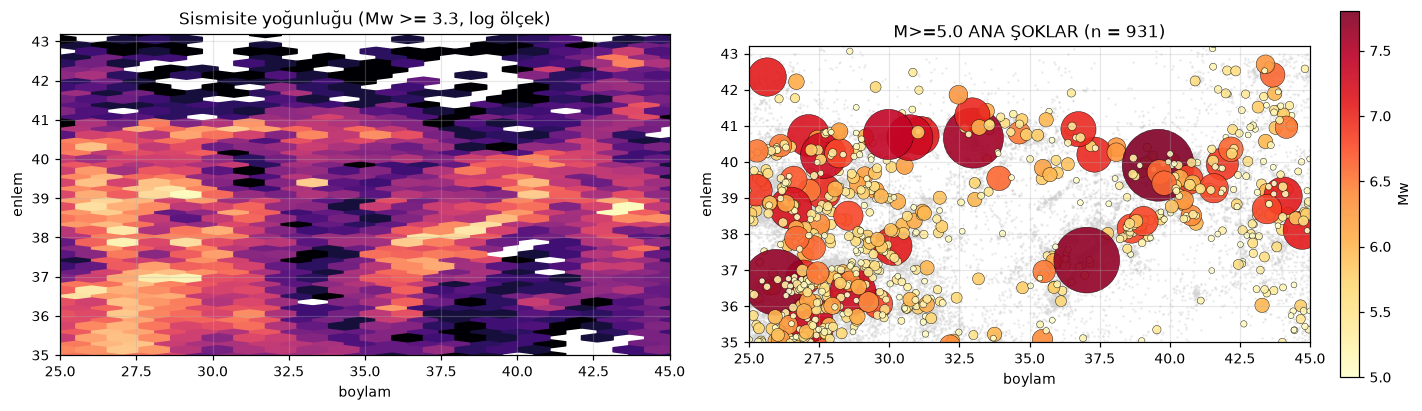

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

small = cat[cat.mw >= mc_model]
axes[0].hexbin(small.lon, small.lat, gridsize=110, cmap="magma", bins="log", mincnt=1)
axes[0].set_title(f"Sismisite yoğunluğu (Mw >= {mc_model:.1f}, log ölçek)")

main5 = dec[(dec.is_mainshock) & (dec.mw >= 5.0)]
axes[1].scatter(small.lon, small.lat, s=0.4, c="lightgray", alpha=0.4)
sc = axes[1].scatter(main5.lon, main5.lat, s=6 ** (main5.mw - 3.5),
                     c=main5.mw, cmap="YlOrRd", edgecolor="k", linewidth=0.3, alpha=0.9)
plt.colorbar(sc, ax=axes[1], label="Mw", fraction=0.03)
axes[1].set_title(f"M>=5.0 ANA ŞOKLAR (n = {len(main5)})")

for ax in axes:
    ax.set_xlim(25, 45); ax.set_ylim(35, 43.2)
    ax.set_xlabel("boylam"); ax.set_ylabel("enlem")
    ax.set_aspect(1 / np.cos(np.radians(39)))
save(fig, "05_harita"); plt.show()

**Okuma:** Yoğunluk, Kuzey Anadolu Fay Zonu (batıda ~40.7°K boyunca doğuya uzanan
şerit), Doğu Anadolu Fay Zonu (güneydoğuya inen kol) ve Batı Anadolu'nun genişleme
rejimini (Ege) izlemelidir. Fay hatlarıyla ilgisiz dağınık bir bulut görülüyorsa
konum verisi bozuktur.

## 6. Declustering doğru mu? — Omori sınaması

Bu, boru hattındaki en güçlü fiziksel doğrulama. Bir ana şoktan sonra artçı oranı
Omori-Utsu yasasına göre azalır: n(t) ∝ (t + c)^(−p), p ≈ 1. Log-log grafikte
bu düz bir çizgidir. Çıkmıyorsa ya declustering ya da zaman ekseni bozuktur.

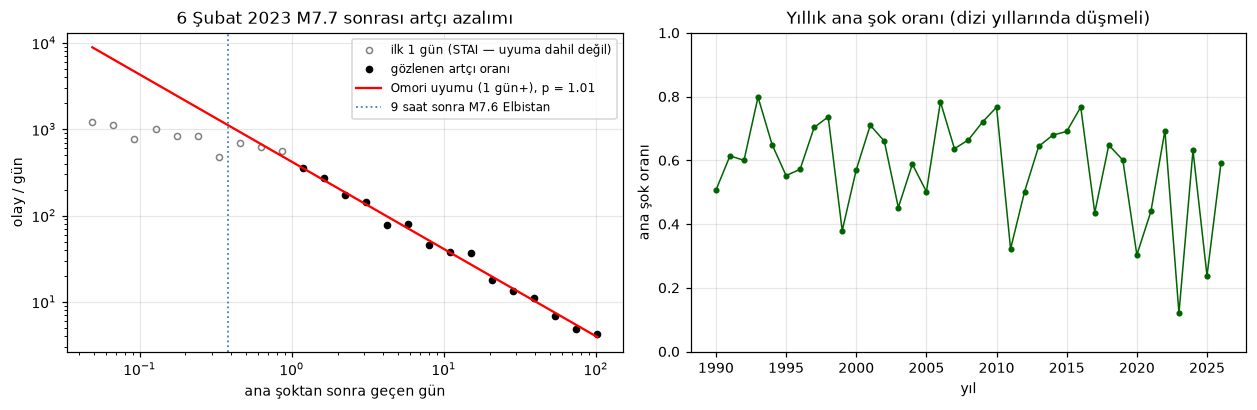

Omori p = 1.01  (1 günden itibaren; literatürde tipik 0.9 - 1.2)
  karşılaştırma: ilk saatler dahil edilseydi p = 0.79 — STAI'nin eğriyi ne kadar yatıklaştırdığı
6 Şubat sonrası 30 gün: 2,113 olay, ana şok oranı %0.9
Katalog geneli ana şok oranı: %54.1


In [7]:
shock = pd.Timestamp("2023-02-06 01:17:32", tz="UTC")
after = cat[(cat.time > shock) & (cat.time < shock + pd.Timedelta(days=120))
            & (cat.mw >= mc_model)]
days = (after.time - shock).dt.total_seconds().to_numpy() / 86400.0

bins = np.logspace(np.log10(1 / 24), np.log10(120), 26)
n, _ = np.histogram(days, bins=bins)
width = np.diff(bins)
rate = n / width
mid = np.sqrt(bins[:-1] * bins[1:])

# Uyum 1. GÜNDEN İTİBAREN yapılır. İlk saatlerde ağ, üst üste binen dalga
# formları yüzünden küçük olayların bir kısmını kaydedemez (kısa vadeli artçı
# eksikliği, STAI). Bu, erken oranı olduğundan düşük gösterip eğriyi
# yatıklaştırır ve p'yi yapay olarak KÜÇÜLTÜR. Erken noktalar grafikte
# gösterilir ama uyuma katılmaz.
FIT_FROM = 1.0
ok = n > 0
fit = ok & (mid >= FIT_FROM)
p, logk = np.polyfit(np.log10(mid[fit]), np.log10(rate[fit]), 1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].loglog(mid[ok & ~fit], rate[ok & ~fit], "o", ms=4, mfc="none", mec="gray",
               label="ilk 1 gün (STAI — uyuma dahil değil)")
axes[0].loglog(mid[fit], rate[fit], "ko", ms=4, label="gözlenen artçı oranı")
axes[0].loglog(mid[ok], 10 ** (logk + p * np.log10(mid[ok])), "r-", lw=1.5,
               label=f"Omori uyumu (1 gün+), p = {-p:.2f}")
axes[0].axvline(0.38, color="steelblue", ls=":", lw=1.2,
                label="9 saat sonra M7.6 Elbistan")
axes[0].set_xlabel("ana şoktan sonra geçen gün"); axes[0].set_ylabel("olay / gün")
axes[0].set_title("6 Şubat 2023 M7.7 sonrası artçı azalımı")
axes[0].legend(fontsize=8)

cl = dec[dec.time >= pd.Timestamp("1990-01-01", tz="UTC")]
frac = cl.set_index("time").is_mainshock.resample("YE").mean()
axes[1].plot(frac.index.year, frac.values, "o-", ms=3, lw=1, color="darkgreen")
axes[1].set_xlabel("yıl"); axes[1].set_ylabel("ana şok oranı")
axes[1].set_title("Yıllık ana şok oranı (dizi yıllarında düşmeli)")
axes[1].set_ylim(0, 1)
save(fig, "06_omori"); plt.show()

p_all = -np.polyfit(np.log10(mid[ok]), np.log10(rate[ok]), 1)[0]
print(f"Omori p = {-p:.2f}  (1 günden itibaren; literatürde tipik 0.9 - 1.2)")
print(f"  karşılaştırma: ilk saatler dahil edilseydi p = {p_all:.2f} — "
      "STAI'nin eğriyi ne kadar yatıklaştırdığı")
w = dec[(dec.time >= shock) & (dec.time < shock + pd.Timedelta(days=30))]
print(f"6 Şubat sonrası 30 gün: {len(w):,} olay, ana şok oranı %{100*w.is_mainshock.mean():.1f}")
print(f"Katalog geneli ana şok oranı: %{100*dec.is_mainshock.mean():.1f}")

**Okuma:** `p` değerinin 0.9-1.2 aralığında çıkması, hem zaman ekseninin hem de
kataloğun tutarlı olduğunu gösteren bağımsız bir doğrulamadır. Sağdaki grafikte
büyük dizi yıllarında (1999 İzmit, 2011 Van, 2023 Kahramanmaraş) ana şok oranının
düşmesi beklenir — o yıllar artçı ağırlıklıdır.

## 7. Hedef etiketlerin dağılımı

,hedef,pozitif,oran_%
0,target_1d_m50,10,0.0014
1,target_1d_m50_all,12,0.0017
2,target_1d_m55,4,0.0006
3,target_1d_m55_all,5,0.0007
4,target_30d_m50,247,0.0356
5,target_30d_m50_all,359,0.0517
6,target_30d_m55,80,0.0115
7,target_30d_m55_all,114,0.0164
8,target_7d_m50,63,0.0091
9,target_7d_m50_all,100,0.0144


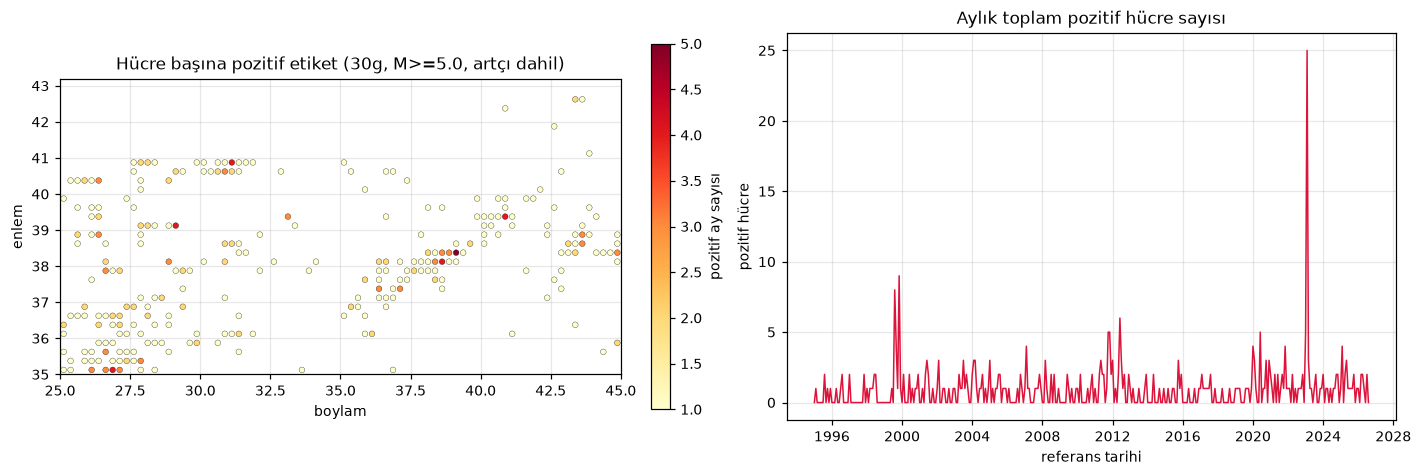

In [8]:
feat = pd.read_parquet(PROC / "grid_features.parquet")
tcols = sorted([c for c in feat.columns if c.startswith("target_")])
summary = pd.DataFrame({
    "hedef": tcols,
    "pozitif": [int(feat[c].sum()) for c in tcols],
    "oran_%": [round(100 * feat[c].mean(), 4) for c in tcols],
})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
pos = feat.groupby(["lat_c", "lon_c"]).target_30d_m50_all.sum().reset_index()
pos = pos[pos.target_30d_m50_all > 0]
sc = axes[0].scatter(pos.lon_c, pos.lat_c, c=pos.target_30d_m50_all,
                     s=14, cmap="YlOrRd", edgecolor="k", linewidth=0.2)
plt.colorbar(sc, ax=axes[0], label="pozitif ay sayısı", fraction=0.03)
axes[0].set_title("Hücre başına pozitif etiket (30g, M>=5.0, artçı dahil)")
axes[0].set_xlim(25, 45); axes[0].set_ylim(35, 43.2)
axes[0].set_aspect(1 / np.cos(np.radians(39)))
axes[0].set_xlabel("boylam"); axes[0].set_ylabel("enlem")

ser = feat.groupby("ref_date").target_30d_m50_all.sum()
axes[1].plot(ser.index, ser.values, lw=1, color="crimson")
axes[1].set_title("Aylık toplam pozitif hücre sayısı")
axes[1].set_xlabel("referans tarihi"); axes[1].set_ylabel("pozitif hücre")
save(fig, "07_hedefler"); plt.show()

**Okuma:** Pozitif oranı binde birkaç mertebesinde — bu **aşırı dengesiz** bir
sınıflandırma problemidir ve doğruluk (accuracy) gibi metrikler burada anlamsızdır.
Bu yüzden değerlendirmede AUC, log-loss ve Molchan diyagramı kullanılıyor.

## 8. Veri kalitesi kontrolleri

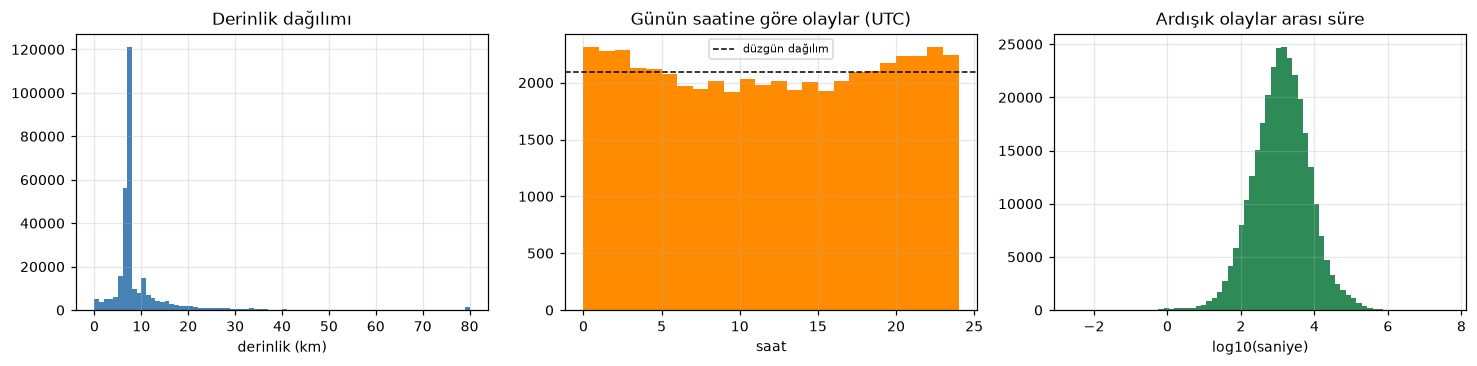

En sık raporlanan derinlikler (sabit değer = operatör varsayılanı):
     7.00 km :  65,606 olay (%21.6)
     7.01 km :   9,543 olay (%3.1)
     6.99 km :   9,180 olay (%3.0)
    10.00 km :   6,867 olay (%2.3)
     5.00 km :   6,851 olay (%2.3)
     6.98 km :   5,905 olay (%1.9)

Aynı saniyeye düşen olay çifti: 86
Mesai saati (08-18 UTC) payı  : %39.6   (düzgün dağılımda beklenen %41.7)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))

axes[0].hist(cat.depth_km.dropna().clip(0, 80), bins=80, color="steelblue")
axes[0].set_title("Derinlik dağılımı"); axes[0].set_xlabel("derinlik (km)")

hours = cat[cat.mw >= mc_model].time.dt.hour
axes[1].hist(hours, bins=24, range=(0, 24), color="darkorange")
axes[1].axhline(len(hours) / 24, color="k", ls="--", lw=1, label="düzgün dağılım")
axes[1].set_title("Günün saatine göre olaylar (UTC)")
axes[1].set_xlabel("saat"); axes[1].legend(fontsize=7)

gaps = cat.time.sort_values().diff().dt.total_seconds().dropna()
axes[2].hist(np.log10(gaps[gaps > 0]), bins=70, color="seagreen")
axes[2].set_title("Ardışık olaylar arası süre")
axes[2].set_xlabel("log10(saniye)")
save(fig, "08_veri_kalitesi"); plt.show()

fixed = cat.depth_km.value_counts().head(6)
print("En sık raporlanan derinlikler (sabit değer = operatör varsayılanı):")
for d, c in fixed.items():
    print(f"  {d:7.2f} km : {c:7,} olay (%{100*c/len(cat):.1f})")
print(f"\nAynı saniyeye düşen olay çifti: {int((gaps == 0).sum()):,}")
print(f"Mesai saati (08-18 UTC) payı  : %{100*hours.between(8,17).mean():.1f}"
      "   (düzgün dağılımda beklenen %41.7)")

**Okuma — üç kontrol:**

1. **Derinlik yığılmaları.** 5, 7, 10 km gibi değerlerde keskin tepeler, derinliğin
   çözülemediği durumlarda operatörün sabit değer atadığını gösterir. Bu normaldir
   ama derinliği öznitelik olarak kullanırken bilinmesi gerekir.
2. **Günün saati.** Gerçek depremler günün saatinden bağımsızdır; mesai saatlerinde
   belirgin fazlalık, katalogda taş ocağı patlatması kaldığına işaret eder. Kandilli
   indiricisi bunları (`Tip=Sm`) zaten filtreliyor.
3. **Olaylar arası süre.** Sıfıra çok yakın yığılma, tekilleştirmenin kaçırdığı
   kopyalara işaret eder.

---
## Özet ve açık maddeler

Bu defter Faz 1'in doğrulama adımıdır. Buradaki grafikler **beklenen davranışı
gösteriyorsa** katalog modellemeye hazırdır; sapma varsa ilgili boru hattı adımına
dönülmelidir.

Bilinen sınırlar:

- **Ağ değişimi tamlıkla sınırlı biçimde düzeltiliyor.** 2003'teki AFAD sıçraması
  Mc ile ele alınıyor ama Mc dönem bazlı, sürekli değil.
- **Mw dönüşümü tek kaynaktan (KOERI) kalibre.** AFAD'ın kendi ML ölçeği farklı
  olabilir; AFAD çift büyüklüklü kayıt vermediği için bu doğrulanamadı.
- **Derinlik henüz öznitelik değil.** Yukarıdaki yığılmalar nedeniyle temkinli
  yaklaşılıyor.